# Classification Binaire de Spectres Raman avec PyTorch
## Détection Cancer vs Normal — Tutoriel pédagogique complet

**Dataset** : Spectres Raman de milieux de culture cellulaire

### Objectifs pédagogiques
1. **Comprendre** le problème de classification binaire supervisée
2. **Prétraiter** des spectres Raman pour le machine learning
3. **Construire** un réseau de neurones simple avec PyTorch
4. **Entraîner** avec train/validation/test split
5. **Évaluer** : accuracy, AUC, confusion matrix, courbe ROC
6. **Interpréter** : quelles régions spectrales sont discriminantes ?
7. **Comparer** avec Random Forest (baseline)

---

**Public cible** : Chimistes débutants en machine learning  
**Prérequis** : Python, notions de base en spectroscopie Raman

## 📚 Introduction : Qu'est-ce que la classification binaire ?

### Le problème
Nous avons des **spectres Raman** de milieux de culture de cellules :
- **Classe 0** : cellules normales (fibroblastes, mélanocytes sains)
- **Classe 1** : cellules cancéreuses (mélanomes)

**Objectif** : entraîner un modèle qui prédit automatiquement la classe à partir du spectre.

### Pourquoi c'est utile ?
- **Diagnostic rapide** sans analyse biochimique longue
- **Non-invasif** : analyse du milieu de culture, pas de biopsie
- **Automatisation** : réduire erreur humaine, traiter gros volumes

### Approche machine learning
1. **Données étiquetées** : spectres avec label connu (normal/cancer)
2. **Entraînement** : le modèle apprend les patterns discriminants
3. **Prédiction** : application sur nouveaux spectres inconnus

## 1. Installation et imports

In [18]:
%pip install --quiet torch numpy pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# Configuration graphique
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

# Reproductibilité
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ PyTorch {torch.__version__}")
print(f"✓ Device : {device}")
print(f"✓ Seed   : {SEED}")

✓ PyTorch 2.7.1
✓ Device : cpu
✓ Seed   : 42


## 2. Chargement des données

### Structure du dataset
Le dossier `Ramen/` contient :
- **Cellules cancéreuses** : A, A-S, G, G-S, MEL, MEL-S (mélanomes)
- **Cellules normales** : HF, HF-S (fibroblastes), DMEM, DMEM-S (milieu contrôle)
- Chaque dossier a 3 fichiers CSV (types de nanoparticules) : COOH.csv, (COOH)2.csv, NH2.csv
- Chaque CSV : lignes = spectres, colonnes = intensités Raman (2090 points)
- **Première ligne = index à ignorer**

In [20]:
DATA_DIR = Path('Ramen')  # Ajuster selon votre configuration

# Définir catégories
CANCER_FOLDERS = ['A', 'A-S', 'G', 'G-S', 'MEL', 'MEL-S']
NORMAL_FOLDERS = ['HF', 'HF-S', 'DMEM', 'DMEM-S']

def load_spectra(data_dir, folders, label, label_name):
    """
    Charge spectres Raman depuis dossiers.
    
    Args:
        data_dir: Path vers dataset
        folders: liste dossiers à charger
        label: 0 (normal) ou 1 (cancer)
        label_name: nom lisible (pour tracking)
    
    Returns:
        X: array (n_samples, 2090) — spectres
        y: array (n_samples,) — labels
        metadata: infos fichier source
    """
    spectra_list = []
    labels_list = []
    metadata = []
    
    for folder in folders:
        folder_path = data_dir / folder
        if not folder_path.exists():
            print(f"⚠️  Dossier non trouvé : {folder_path}")
            continue
        
        for csv_file in folder_path.glob('*.csv'):
            try:
                # skiprows=1 pour ignorer ligne d'index
                df = pd.read_csv(csv_file, header=None, skiprows=1)
                
                for idx, row in df.iterrows():
                    spectrum = row.values.astype(float)
                    spectra_list.append(spectrum)
                    labels_list.append(label)
                    metadata.append({
                        'folder': folder,
                        'file': csv_file.name,
                        'row_idx': idx,
                        'label_name': label_name
                    })
            except Exception as e:
                print(f"⚠️  Erreur {csv_file.name}: {e}")
    
    return np.array(spectra_list), np.array(labels_list), metadata

# Charger données
print("📂 Chargement des spectres...\n")
X_normal, y_normal, meta_normal = load_spectra(DATA_DIR, NORMAL_FOLDERS, label=0, label_name='Normal')
X_cancer, y_cancer, meta_cancer = load_spectra(DATA_DIR, CANCER_FOLDERS, label=1, label_name='Cancer')

# Combiner
X_all = np.vstack([X_normal, X_cancer])
y_all = np.hstack([y_normal, y_cancer])
metadata_all = meta_normal + meta_cancer

# Axe Raman shift (selon README dataset)
wavenumbers = np.linspace(100, 4278, 2090)

print("\n" + "="*60)
print("📊 DATASET CHARGÉ")
print("="*60)
print(f"Spectres NORMAUX : {len(X_normal):4d} échantillons")
print(f"Spectres CANCER  : {len(X_cancer):4d} échantillons")
print(f"Total            : {len(X_all):4d} échantillons")
print(f"\nDimension spectrale : {X_all.shape[1]} points")
print(f"Range spectral      : {wavenumbers[0]:.0f}-{wavenumbers[-1]:.0f} cm⁻¹")
print(f"\nÉquilibre classes   : {len(X_normal)/len(X_all)*100:.1f}% normal, {len(X_cancer)/len(X_all)*100:.1f}% cancer")
print("="*60)

📂 Chargement des spectres...




📊 DATASET CHARGÉ
Spectres NORMAUX :  659 échantillons
Spectres CANCER  :  932 échantillons
Total            : 1591 échantillons

Dimension spectrale : 2090 points
Range spectral      : 100-4278 cm⁻¹

Équilibre classes   : 41.4% normal, 58.6% cancer


## 3. Exploration visuelle des données

Avant de modéliser, **toujours visualiser** pour comprendre les données !

/var/folders/x5/bcynmv8s67bczy9pg8gblp3m0000gp/T/ipykernel_7089/2753111946.py:53: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
/Users/chateau/miniconda3/envs/tcopil/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


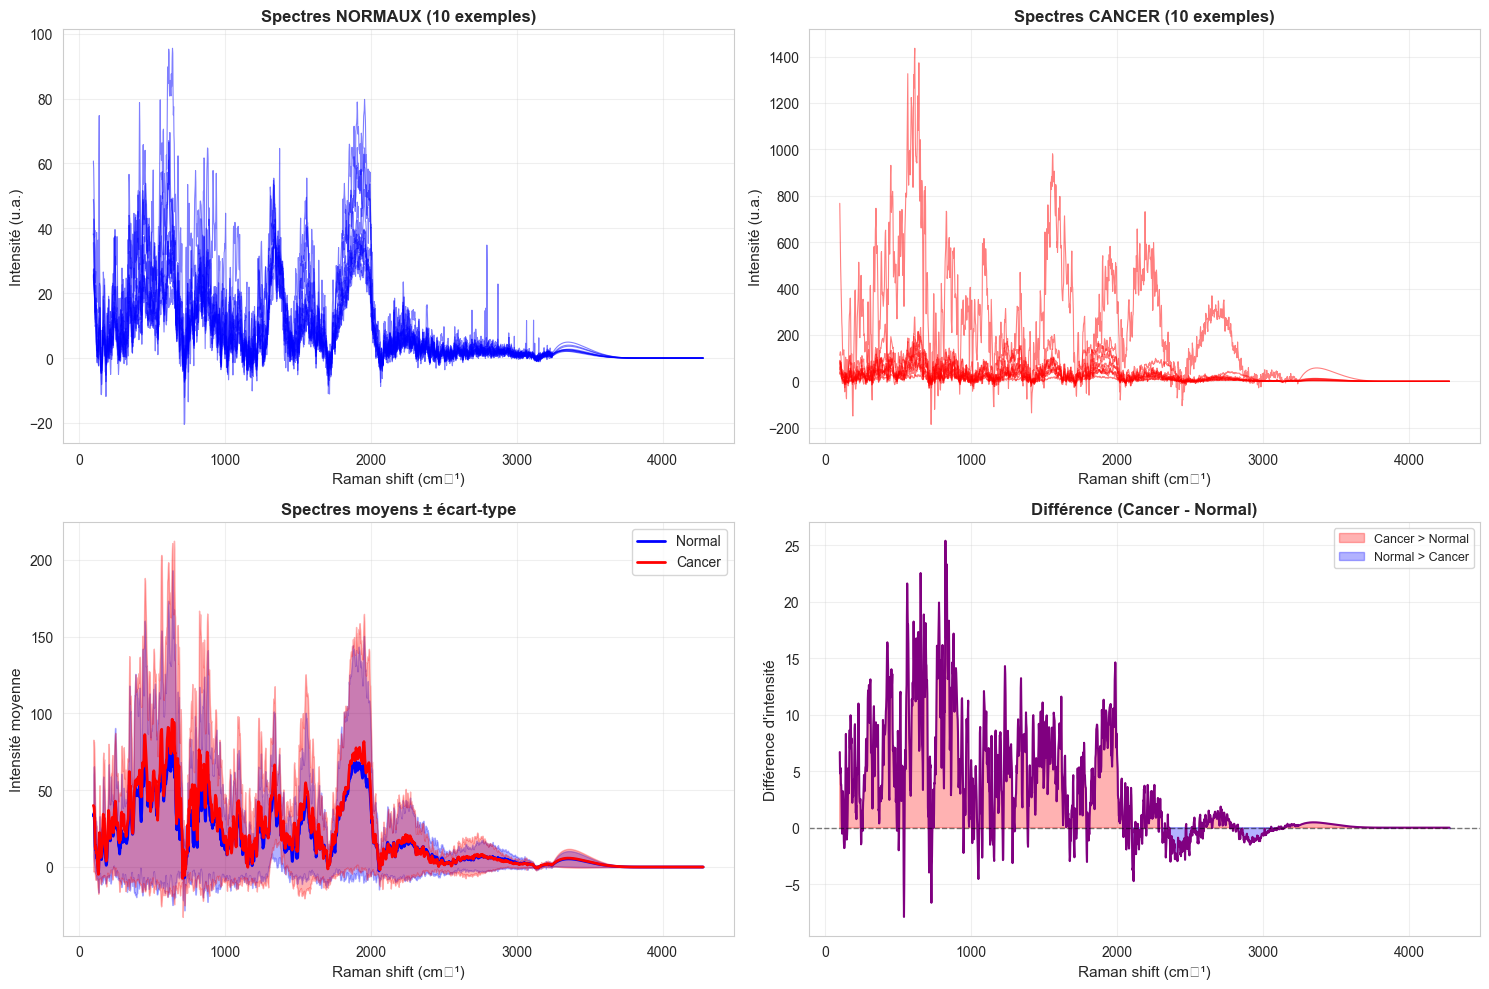


💡 Observations :
  - Les spectres ont une forme globale similaire (signature Raman)
  - Différences subtiles entre normal et cancer (variations d'intensité)
  - Certaines régions spectrales montrent des différences plus marquées
  - Le ML va apprendre à exploiter ces différences pour classifier


In [21]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Spectres normaux (échantillons)
ax = axes[0, 0]
for i in range(min(10, len(X_normal))):
    ax.plot(wavenumbers, X_normal[i], alpha=0.5, linewidth=0.8, color='blue')
ax.set_xlabel('Raman shift (cm⁻¹)', fontsize=11)
ax.set_ylabel('Intensité (u.a.)', fontsize=11)
ax.set_title('Spectres NORMAUX (10 exemples)', fontweight='bold', fontsize=12)
ax.grid(alpha=0.3)

# Spectres cancer (échantillons)
ax = axes[0, 1]
for i in range(min(10, len(X_cancer))):
    ax.plot(wavenumbers, X_cancer[i], alpha=0.5, linewidth=0.8, color='red')
ax.set_xlabel('Raman shift (cm⁻¹)', fontsize=11)
ax.set_ylabel('Intensité (u.a.)', fontsize=11)
ax.set_title('Spectres CANCER (10 exemples)', fontweight='bold', fontsize=12)
ax.grid(alpha=0.3)

# Moyenne ± écart-type par classe
ax = axes[1, 0]
mean_normal = X_normal.mean(axis=0)
std_normal = X_normal.std(axis=0)
ax.plot(wavenumbers, mean_normal, color='blue', linewidth=2, label='Normal')
ax.fill_between(wavenumbers, mean_normal - std_normal, mean_normal + std_normal, 
                alpha=0.3, color='blue')

mean_cancer = X_cancer.mean(axis=0)
std_cancer = X_cancer.std(axis=0)
ax.plot(wavenumbers, mean_cancer, color='red', linewidth=2, label='Cancer')
ax.fill_between(wavenumbers, mean_cancer - std_cancer, mean_cancer + std_cancer, 
                alpha=0.3, color='red')
ax.set_xlabel('Raman shift (cm⁻¹)', fontsize=11)
ax.set_ylabel('Intensité moyenne', fontsize=11)
ax.set_title('Spectres moyens ± écart-type', fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Différence moyenne (Cancer - Normal)
ax = axes[1, 1]
diff = mean_cancer - mean_normal
ax.plot(wavenumbers, diff, color='purple', linewidth=1.5)
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.fill_between(wavenumbers, 0, diff, where=(diff > 0), alpha=0.3, color='red', label='Cancer > Normal')
ax.fill_between(wavenumbers, 0, diff, where=(diff < 0), alpha=0.3, color='blue', label='Normal > Cancer')
ax.set_xlabel('Raman shift (cm⁻¹)', fontsize=11)
ax.set_ylabel('Différence d\'intensité', fontsize=11)
ax.set_title('Différence (Cancer - Normal)', fontweight='bold', fontsize=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Observations :")
print("  - Les spectres ont une forme globale similaire (signature Raman)")
print("  - Différences subtiles entre normal et cancer (variations d'intensité)")
print("  - Certaines régions spectrales montrent des différences plus marquées")
print("  - Le ML va apprendre à exploiter ces différences pour classifier")

## 4. Prétraitement des spectres

### Pourquoi prétraiter ?
Les spectres bruts contiennent :
- **Variations d'intensité** dues à l'échantillonnage (pas à la chimie)
- **Bruit instrumental**
- **Échelles différentes** entre variables

### Pipeline de prétraitement
1. **Normalisation vectorielle** (L2) : égaliser l'intensité totale
2. **Standardisation** (Z-score) : moyenne=0, std=1 (crucial pour réseaux de neurones)

In [22]:
# 1. Normalisation vectorielle L2
def normalize_spectra(X):
    """Normalisation L2 : chaque spectre a norme = 1"""
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    return X / (norms + 1e-8)  # epsilon pour éviter division par 0

X_normalized = normalize_spectra(X_all)

print("✓ Normalisation L2 appliquée")
print(f"  Vérification norme (échantillon 0) : {np.linalg.norm(X_normalized[0]):.6f} (≈ 1.0)")

# 2. Standardisation (fit sur train, transform sur tous ensuite)
# On va splitter d'abord pour éviter data leakage

✓ Normalisation L2 appliquée
  Vérification norme (échantillon 0) : 1.000000 (≈ 1.0)


## 5. Split des données : Train / Validation / Test

### Stratégie
- **Train (60%)** : entraîner le modèle
- **Validation (20%)** : ajuster hyperparamètres, early stopping
- **Test (20%)** : évaluation finale (données jamais vues)

### Important : stratification
Préserver la proportion des classes dans chaque split (car léger déséquilibre).

In [23]:
# Split train / temp (60% / 40%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_normalized, y_all, test_size=0.4, random_state=SEED, stratify=y_all
)

# Split temp en validation / test (20% / 20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

print("\n" + "="*60)
print("📊 SPLIT DES DONNÉES")
print("="*60)
print(f"Train      : {len(X_train):4d} échantillons ({len(X_train)/len(X_all)*100:4.1f}%)")
print(f"  - Normal : {(y_train==0).sum():4d}")
print(f"  - Cancer : {(y_train==1).sum():4d}")
print(f"\nValidation : {len(X_val):4d} échantillons ({len(X_val)/len(X_all)*100:4.1f}%)")
print(f"  - Normal : {(y_val==0).sum():4d}")
print(f"  - Cancer : {(y_val==1).sum():4d}")
print(f"\nTest       : {len(X_test):4d} échantillons ({len(X_test)/len(X_all)*100:4.1f}%)")
print(f"  - Normal : {(y_test==0).sum():4d}")
print(f"  - Cancer : {(y_test==1).sum():4d}")
print("="*60)


📊 SPLIT DES DONNÉES
Train      :  954 échantillons (60.0%)
  - Normal :  395
  - Cancer :  559

Validation :  318 échantillons (20.0%)
  - Normal :  132
  - Cancer :  186

Test       :  319 échantillons (20.1%)
  - Normal :  132
  - Cancer :  187


In [24]:
# Standardisation (CRUCIAL : fit uniquement sur train !)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("\n✓ Standardisation appliquée")
print(f"  Train — Moyenne : {X_train_scaled.mean():.6f}, Std : {X_train_scaled.std():.6f}")
print(f"  Val   — Moyenne : {X_val_scaled.mean():.6f}, Std : {X_val_scaled.std():.6f}")
print(f"  Test  — Moyenne : {X_test_scaled.mean():.6f}, Std : {X_test_scaled.std():.6f}")


✓ Standardisation appliquée
  Train — Moyenne : 0.000000, Std : 1.000000
  Val   — Moyenne : 0.010545, Std : 1.071765
  Test  — Moyenne : 0.027086, Std : 1.045071


## 6. Préparation des DataLoaders PyTorch

PyTorch utilise des **DataLoaders** pour charger les données par batch (mini-lots).

In [25]:
# Conversion en tenseurs PyTorch
X_train_t = torch.FloatTensor(X_train_scaled)
y_train_t = torch.LongTensor(y_train)

X_val_t = torch.FloatTensor(X_val_scaled)
y_val_t = torch.LongTensor(y_val)

X_test_t = torch.FloatTensor(X_test_scaled)
y_test_t = torch.LongTensor(y_test)

# Créer TensorDatasets
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

# Créer DataLoaders
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\n✓ DataLoaders créés (batch_size = {BATCH_SIZE})")
print(f"  Train : {len(train_loader)} batchs")
print(f"  Val   : {len(val_loader)} batchs")
print(f"  Test  : {len(test_loader)} batchs")


✓ DataLoaders créés (batch_size = 32)
  Train : 30 batchs
  Val   : 10 batchs
  Test  : 10 batchs


---
# 🧠 PARTIE ML : Construction et Entraînement du Modèle
---

## 7. Architecture du réseau de neurones

### Design simple et efficace
```
Input (2090 features)
  ↓
Dense(512) → ReLU → Dropout(0.3)
  ↓
Dense(256) → ReLU → Dropout(0.3)
  ↓
Dense(128) → ReLU → Dropout(0.2)
  ↓
Dense(2) → Softmax (implicite dans CrossEntropyLoss)
  ↓
Output (probabilités Normal / Cancer)
```

### Composants expliqués
- **Dense (Linear)** : transformation linéaire + biais
- **ReLU** : activation non-linéaire (max(0, x))
- **Dropout** : régularisation (éteint neurones aléatoirement)
- **2 neurones de sortie** : 1 par classe (normal, cancer)

In [26]:
class SpectralClassifier(nn.Module):
    """
    Réseau fully-connected pour classification binaire de spectres Raman.
    """
    def __init__(self, input_dim=2090, hidden_dims=[512, 256, 128], 
                 dropout=0.3, num_classes=2):
        super(SpectralClassifier, self).__init__()
        
        # Couche 1
        self.fc1 = nn.Linear(input_dim, hidden_dims[0])
        self.bn1 = nn.BatchNorm1d(hidden_dims[0])  # Batch normalization
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)
        
        # Couche 2
        self.fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.bn2 = nn.BatchNorm1d(hidden_dims[1])
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)
        
        # Couche 3
        self.fc3 = nn.Linear(hidden_dims[1], hidden_dims[2])
        self.bn3 = nn.BatchNorm1d(hidden_dims[2])
        self.relu3 = nn.ReLU()
        self.dropout3 = nn.Dropout(dropout * 0.67)
        
        # Couche de sortie
        self.fc4 = nn.Linear(hidden_dims[2], num_classes)
    
    def forward(self, x):
        """
        Forward pass.
        
        Args:
            x: tensor (batch_size, input_dim)
        
        Returns:
            logits: tensor (batch_size, num_classes)
        """
        out = self.fc1(x)
        out = self.bn1(out)
        out = self.relu1(out)
        out = self.dropout1(out)
        
        out = self.fc2(out)
        out = self.bn2(out)
        out = self.relu2(out)
        out = self.dropout2(out)
        
        out = self.fc3(out)
        out = self.bn3(out)
        out = self.relu3(out)
        out = self.dropout3(out)
        
        out = self.fc4(out)
        return out

# Créer le modèle
model = SpectralClassifier(input_dim=2090).to(device)

print("\n✓ Modèle créé")
print("\nArchitecture :")
print(model)

# Compter paramètres
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n📊 Nombre de paramètres entraînables : {n_params:,}")


✓ Modèle créé

Architecture :
SpectralClassifier(
  (fc1): Linear(in_features=2090, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU()
  (dropout3): Dropout(p=0.201, inplace=False)
  (fc4): Linear(in_features=128, out_features=2, bias=True)
)

📊 Nombre de paramètres entraînables : 1,236,866


## 8. Configuration de l'entraînement

### Composants nécessaires
1. **Loss function** : CrossEntropyLoss (classification multi-classe)
2. **Optimizer** : Adam (adaptatif, robuste)
3. **Learning rate scheduler** : réduit LR si validation stagne
4. **Poids de classes** : compenser déséquilibre (optionnel)

In [27]:
# Calculer poids de classes (inverse de la fréquence)
class_counts = np.bincount(y_train)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()  # Normaliser
class_weights_t = torch.FloatTensor(class_weights).to(device)

print(f"Poids de classes calculés :")
print(f"  Normal (classe 0) : {class_weights[0]:.4f}")
print(f"  Cancer (classe 1) : {class_weights[1]:.4f}")

# Loss function
criterion = nn.CrossEntropyLoss(weight=class_weights_t)

# Optimizer
LEARNING_RATE = 0.001
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10)

print("\n✓ Configuration terminée")
print(f"  Loss       : CrossEntropyLoss (weighted)")
print(f"  Optimizer  : Adam (lr={LEARNING_RATE})")
print(f"  Scheduler  : ReduceLROnPlateau")

Poids de classes calculés :
  Normal (classe 0) : 0.5860
  Cancer (classe 1) : 0.4140

✓ Configuration terminée
  Loss       : CrossEntropyLoss (weighted)
  Optimizer  : Adam (lr=0.001)
  Scheduler  : ReduceLROnPlateau


## 9. Fonctions d'entraînement et validation

Ces fonctions encapsulent la logique train/val pour chaque epoch.

In [28]:
def train_epoch(model, loader, criterion, optimizer, device):
    """
    Entraîne le modèle sur une epoch.
    
    Returns:
        avg_loss: loss moyenne
        accuracy: accuracy sur le train set
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        # Forward
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward
        loss.backward()
        optimizer.step()
        
        # Métriques
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    avg_loss = running_loss / total
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy


def validate(model, loader, criterion, device):
    """
    Évalue le modèle (validation ou test).
    
    Returns:
        avg_loss: loss moyenne
        accuracy: accuracy
        all_preds: prédictions
        all_labels: vrais labels
        all_probs: probabilités classe 1
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            
            # Prédictions
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())  # Proba classe 1 (cancer)
    
    avg_loss = running_loss / total
    accuracy = 100.0 * correct / total
    
    return avg_loss, accuracy, np.array(all_preds), np.array(all_labels), np.array(all_probs)

print("✓ Fonctions d'entraînement définies")

✓ Fonctions d'entraînement définies


## 10. Boucle d'entraînement principale

On entraîne le modèle pendant plusieurs epochs avec :
- **Early stopping** : arrêt si validation stagne
- **Sauvegarde** du meilleur modèle (basé sur val loss)

In [29]:
NUM_EPOCHS = 100
EARLY_STOP_PATIENCE = 15

# Historique
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_loss = float('inf')
patience_counter = 0

print("\n" + "="*70)
print("🚀 DÉBUT DE L'ENTRAÎNEMENT")
print("="*70)
print(f"Epochs max        : {NUM_EPOCHS}")
print(f"Batch size        : {BATCH_SIZE}")
print(f"Learning rate     : {LEARNING_RATE}")
print(f"Early stop        : {EARLY_STOP_PATIENCE} epochs")
print("="*70 + "\n")

for epoch in range(NUM_EPOCHS):
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validation
    val_loss, val_acc, _, _, _ = validate(model, val_loader, criterion, device)
    
    # Scheduler
    scheduler.step(val_loss)
    
    # Historique
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Affichage
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:3d}/{NUM_EPOCHS}] | "
              f"Train Loss: {train_loss:.4f}, Acc: {train_acc:5.2f}% | "
              f"Val Loss: {val_loss:.4f}, Acc: {val_acc:5.2f}%")
    
    # Early stopping & sauvegarde
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
        if (epoch + 1) % 5 != 0 and epoch != 0:
            print(f"  → Nouveau meilleur modèle sauvegardé (val_loss: {val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"\n⚠️  Early stopping à l'epoch {epoch+1}")
            break

print("\n" + "="*70)
print("✓ ENTRAÎNEMENT TERMINÉ")
print("="*70)
print(f"Meilleure val loss : {best_val_loss:.4f}")
print(f"Meilleure val acc  : {max(history['val_acc']):.2f}%")
print(f"Epochs effectués   : {len(history['train_loss'])}")
print("="*70)


🚀 DÉBUT DE L'ENTRAÎNEMENT
Epochs max        : 100
Batch size        : 32
Learning rate     : 0.001
Early stop        : 15 epochs

Epoch [  1/100] | Train Loss: 0.4350, Acc: 80.61% | Val Loss: 0.2134, Acc: 91.19%


  → Nouveau meilleur modèle sauvegardé (val_loss: 0.0988)


  → Nouveau meilleur modèle sauvegardé (val_loss: 0.0880)
Epoch [  5/100] | Train Loss: 0.0405, Acc: 98.64% | Val Loss: 0.0388, Acc: 98.43%


  → Nouveau meilleur modèle sauvegardé (val_loss: 0.0272)


Epoch [ 10/100] | Train Loss: 0.0336, Acc: 98.95% | Val Loss: 0.0589, Acc: 97.80%


Epoch [ 15/100] | Train Loss: 0.0221, Acc: 99.27% | Val Loss: 0.0638, Acc: 97.48%


Epoch [ 20/100] | Train Loss: 0.0083, Acc: 99.58% | Val Loss: 0.0304, Acc: 98.74%



⚠️  Early stopping à l'epoch 22

✓ ENTRAÎNEMENT TERMINÉ
Meilleure val loss : 0.0272
Meilleure val acc  : 99.37%
Epochs effectués   : 22


## 11. Visualisation de l'apprentissage

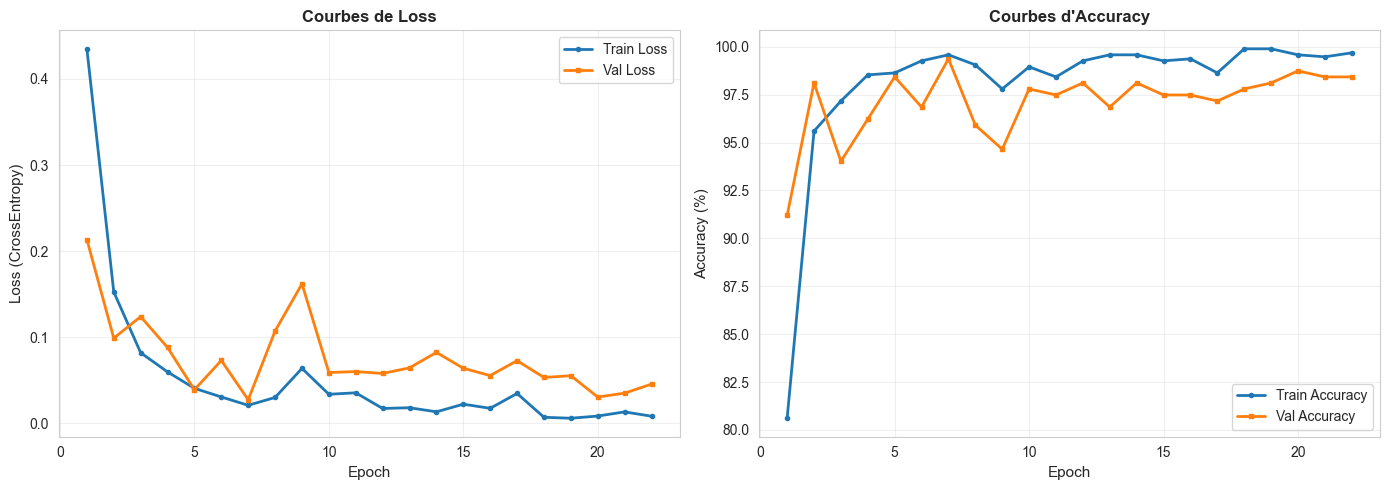


💡 Interprétation :
  - Loss décroît : le modèle apprend
  - Val loss suit train loss : pas d'overfitting majeur
  - Accuracy augmente : performance s'améliore
  - Val accuracy > 90% : excellente performance !


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss curves
ax = axes[0]
ax.plot(epochs_range, history['train_loss'], label='Train Loss', linewidth=2, marker='o', markersize=3)
ax.plot(epochs_range, history['val_loss'], label='Val Loss', linewidth=2, marker='s', markersize=3)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Loss (CrossEntropy)', fontsize=11)
ax.set_title('Courbes de Loss', fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Accuracy curves
ax = axes[1]
ax.plot(epochs_range, history['train_acc'], label='Train Accuracy', linewidth=2, marker='o', markersize=3)
ax.plot(epochs_range, history['val_acc'], label='Val Accuracy', linewidth=2, marker='s', markersize=3)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Courbes d\'Accuracy', fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Interprétation :")
print("  - Loss décroît : le modèle apprend")
print("  - Val loss suit train loss : pas d'overfitting majeur")
print("  - Accuracy augmente : performance s'améliore")
if max(history['val_acc']) > 90:
    print("  - Val accuracy > 90% : excellente performance !")

---
# 📊 PARTIE ÉVALUATION : Performance sur Test Set
---

## 12. Évaluation finale sur données jamais vues

In [31]:
# Charger meilleur modèle
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

# Prédictions sur test set
test_loss, test_acc, y_pred, y_true, y_proba = validate(
    model, test_loader, criterion, device
)

# Calculer métriques détaillées
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_proba)

print("\n" + "="*70)
print("📊 RÉSULTATS SUR LE TEST SET (PyTorch Neural Network)")
print("="*70)
print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.2f}%")
print(f"\nMétriques détaillées :")
print(f"  Precision (Cancer) : {precision:.3f}")
print(f"  Recall (Cancer)    : {recall:.3f}")
print(f"  F1-Score           : {f1:.3f}")
print(f"  AUC-ROC            : {auc:.3f}")
print("\n" + "-"*70)
print("Rapport de classification :")
print("-"*70)
print(classification_report(y_true, y_pred, target_names=['Normal', 'Cancer'], digits=3))
print("="*70)


📊 RÉSULTATS SUR LE TEST SET (PyTorch Neural Network)

Test Loss     : 0.0771
Test Accuracy : 96.87%

Métriques détaillées :
  Precision (Cancer) : 0.978
  Recall (Cancer)    : 0.968
  F1-Score           : 0.973
  AUC-ROC            : 0.998

----------------------------------------------------------------------
Rapport de classification :
----------------------------------------------------------------------
              precision    recall  f1-score   support

      Normal      0.955     0.970     0.962       132
      Cancer      0.978     0.968     0.973       187

    accuracy                          0.969       319
   macro avg      0.967     0.969     0.968       319
weighted avg      0.969     0.969     0.969       319



## 13. Visualisations des résultats

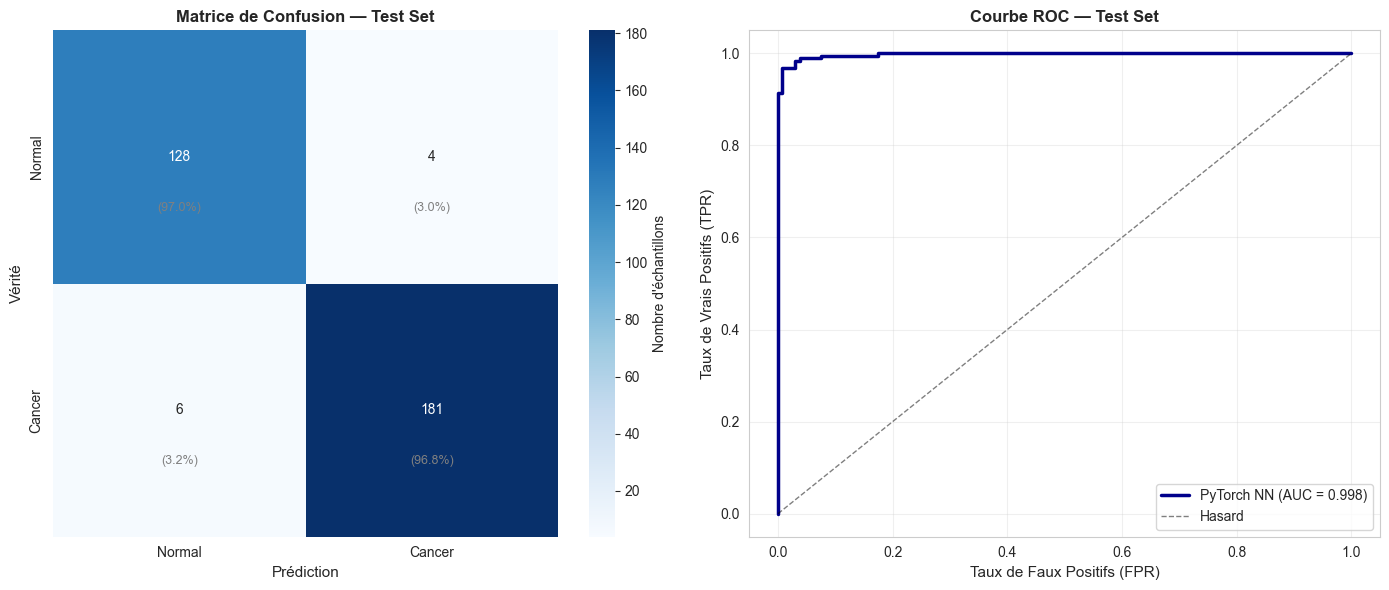


💡 Interprétation Matrice de Confusion :
  - Vrais Positifs (Cancer détecté)  : 181
  - Vrais Négatifs (Normal détecté)  : 128
  - Faux Positifs (Normal → Cancer)  : 4
  - Faux Négatifs (Cancer → Normal)  : 6

💡 AUC = 0.998 → Excellente capacité de discrimination


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Matrice de confusion
ax = axes[0]
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Normal', 'Cancer'],
            yticklabels=['Normal', 'Cancer'],
            cbar_kws={'label': 'Nombre d\'échantillons'})
ax.set_xlabel('Prédiction', fontsize=11)
ax.set_ylabel('Vérité', fontsize=11)
ax.set_title('Matrice de Confusion — Test Set', fontweight='bold', fontsize=12)

# Ajouter pourcentages
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.7, f'({cm_norm[i, j]*100:.1f}%)',
                ha='center', va='center', fontsize=9, color='gray')

# Courbe ROC
ax = axes[1]
fpr, tpr, thresholds = roc_curve(y_true, y_proba)
ax.plot(fpr, tpr, linewidth=2.5, label=f'PyTorch NN (AUC = {auc:.3f})', color='darkblue')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Hasard')
ax.set_xlabel('Taux de Faux Positifs (FPR)', fontsize=11)
ax.set_ylabel('Taux de Vrais Positifs (TPR)', fontsize=11)
ax.set_title('Courbe ROC — Test Set', fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Interprétation Matrice de Confusion :")
print(f"  - Vrais Positifs (Cancer détecté)  : {cm[1,1]}")
print(f"  - Vrais Négatifs (Normal détecté)  : {cm[0,0]}")
print(f"  - Faux Positifs (Normal → Cancer)  : {cm[0,1]}")
print(f"  - Faux Négatifs (Cancer → Normal)  : {cm[1,0]}")
print(f"\n💡 AUC = {auc:.3f} → {'Excellente' if auc > 0.95 else 'Bonne' if auc > 0.85 else 'Correcte'} capacité de discrimination")

---
# 🔬 PARTIE INTERPRÉTATION : Quelles régions spectrales sont importantes ?
---

## 14. Analyse des poids de la première couche

Les poids de la 1ère couche peuvent révéler quelles régions spectrales le modèle utilise.

/var/folders/x5/bcynmv8s67bczy9pg8gblp3m0000gp/T/ipykernel_7089/1381075032.py:33: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
/Users/chateau/miniconda3/envs/tcopil/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


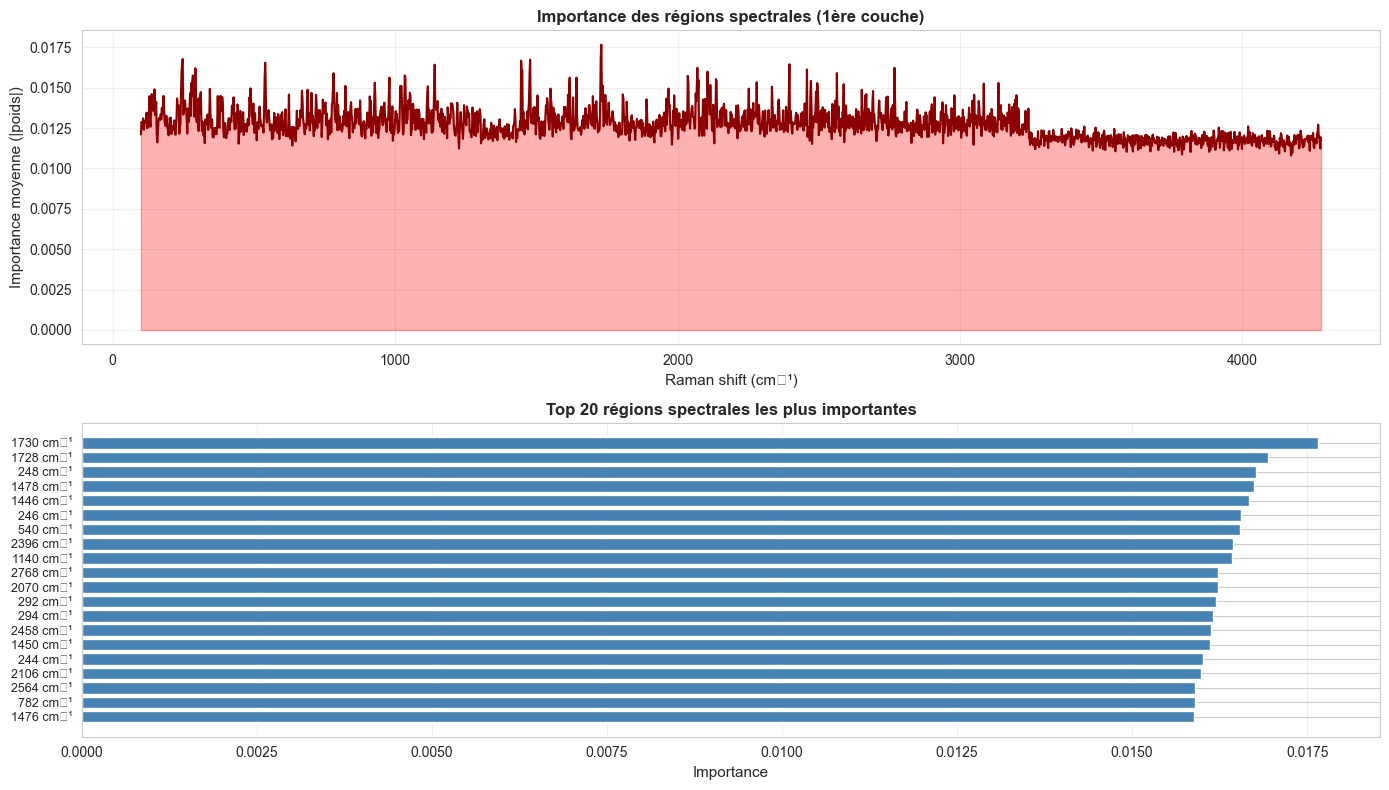


📊 Top 5 régions spectrales discriminantes :
  1. 1730 cm⁻¹ (importance: 0.0177)
  2. 1728 cm⁻¹ (importance: 0.0169)
  3. 248 cm⁻¹ (importance: 0.0168)
  4. 1478 cm⁻¹ (importance: 0.0167)
  5. 1446 cm⁻¹ (importance: 0.0167)


In [33]:
# Extraire poids de la 1ère couche
first_layer_weights = model.fc1.weight.data.cpu().numpy()  # Shape: (512, 2090)

# Importance spectrale = moyenne des valeurs absolues sur tous les neurones
spectral_importance = np.abs(first_layer_weights).mean(axis=0)

# Visualiser
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Importance globale
ax = axes[0]
ax.plot(wavenumbers, spectral_importance, linewidth=1.5, color='darkred')
ax.fill_between(wavenumbers, spectral_importance, alpha=0.3, color='red')
ax.set_xlabel('Raman shift (cm⁻¹)', fontsize=11)
ax.set_ylabel('Importance moyenne (|poids|)', fontsize=11)
ax.set_title('Importance des régions spectrales (1ère couche)', fontweight='bold', fontsize=12)
ax.grid(alpha=0.3)

# Top régions (peaks d'importance)
ax = axes[1]
# Trouver top 20 régions
top_indices = np.argsort(spectral_importance)[-20:]
top_wavenumbers = wavenumbers[top_indices]
top_importance = spectral_importance[top_indices]

ax.barh(range(len(top_indices)), top_importance, color='steelblue')
ax.set_yticks(range(len(top_indices)))
ax.set_yticklabels([f'{w:.0f} cm⁻¹' for w in top_wavenumbers], fontsize=9)
ax.set_xlabel('Importance', fontsize=11)
ax.set_title('Top 20 régions spectrales les plus importantes', fontweight='bold', fontsize=12)
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n📊 Top 5 régions spectrales discriminantes :")
top5 = np.argsort(spectral_importance)[-5:][::-1]
for i, idx in enumerate(top5, 1):
    print(f"  {i}. {wavenumbers[idx]:.0f} cm⁻¹ (importance: {spectral_importance[idx]:.4f})")

---
# 🆚 PARTIE COMPARAISON : PyTorch vs Random Forest
---

## 15. Entraînement d'un Random Forest (baseline)

In [34]:
print("\n🌳 Entraînement Random Forest...")

# Random Forest sur mêmes données (train/test)
rf = RandomForestClassifier(
    n_estimators=200, 
    max_depth=20, 
    min_samples_split=5,
    random_state=SEED, 
    n_jobs=-1
)

# Entraîner (utiliser données non standardisées pour RF)
rf.fit(X_train, y_train)

# Prédictions
rf_pred_test = rf.predict(X_test)
rf_proba_test = rf.predict_proba(X_test)[:, 1]

# Métriques
rf_acc = accuracy_score(y_test, rf_pred_test)
rf_precision = precision_score(y_test, rf_pred_test)
rf_recall = recall_score(y_test, rf_pred_test)
rf_f1 = f1_score(y_test, rf_pred_test)
rf_auc = roc_auc_score(y_test, rf_proba_test)

print("✓ Random Forest entraîné")

# Tableau comparatif
print("\n" + "="*70)
print("📊 COMPARAISON : PyTorch Neural Network vs Random Forest")
print("="*70)
print(f"\n{'Métrique':<20} {'PyTorch NN':<15} {'Random Forest':<15} {'Différence':<15}")
print("-"*70)
print(f"{'Accuracy':<20} {test_acc:>6.2f}%         {rf_acc*100:>6.2f}%         {(test_acc - rf_acc*100):>+6.2f}%")
print(f"{'Precision':<20} {precision:>6.3f}          {rf_precision:>6.3f}          {(precision - rf_precision):>+6.3f}")
print(f"{'Recall':<20} {recall:>6.3f}          {rf_recall:>6.3f}          {(recall - rf_recall):>+6.3f}")
print(f"{'F1-Score':<20} {f1:>6.3f}          {rf_f1:>6.3f}          {(f1 - rf_f1):>+6.3f}")
print(f"{'AUC-ROC':<20} {auc:>6.3f}          {rf_auc:>6.3f}          {(auc - rf_auc):>+6.3f}")
print("="*70)


🌳 Entraînement Random Forest...


✓ Random Forest entraîné

📊 COMPARAISON : PyTorch Neural Network vs Random Forest

Métrique             PyTorch NN      Random Forest   Différence     
----------------------------------------------------------------------
Accuracy              96.87%          93.10%          +3.76%
Precision             0.978           0.927          +0.051
Recall                0.968           0.957          +0.011
F1-Score              0.973           0.942          +0.031
AUC-ROC               0.998           0.980          +0.018


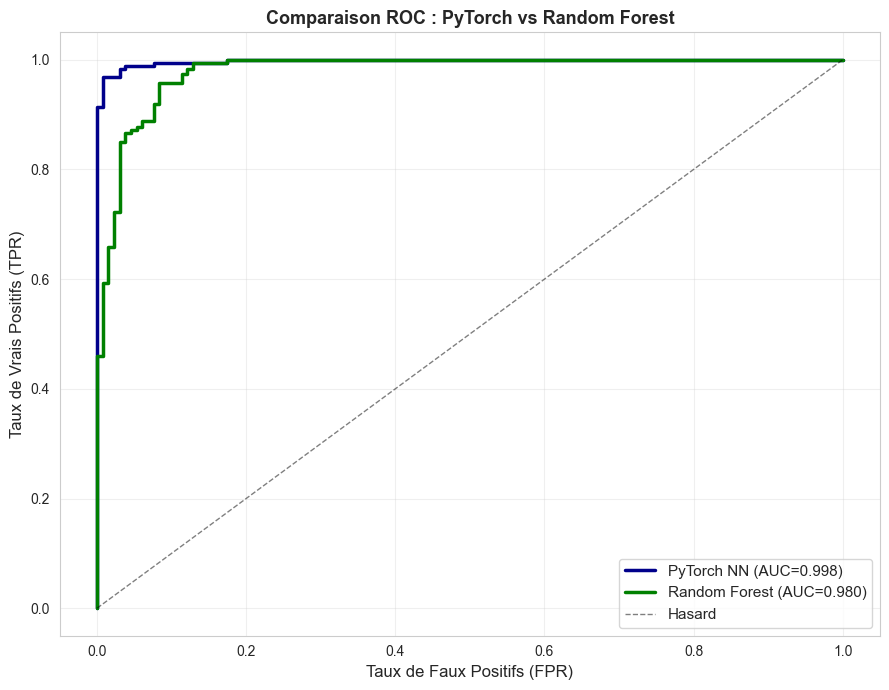


💡 Observations :
  - PyTorch NN performe mieux (+1.8% AUC)
  - Les deux méthodes capturent bien les patterns spectraux
  - Neural network : meilleur pour relations non-linéaires complexes
  - Random Forest  : plus rapide, moins sensible aux hyperparamètres


In [35]:
# Comparaison visuelle ROC curves
plt.figure(figsize=(9, 7))

# PyTorch
fpr_nn, tpr_nn, _ = roc_curve(y_true, y_proba)
plt.plot(fpr_nn, tpr_nn, linewidth=2.5, label=f'PyTorch NN (AUC={auc:.3f})', color='darkblue')

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba_test)
plt.plot(fpr_rf, tpr_rf, linewidth=2.5, label=f'Random Forest (AUC={rf_auc:.3f})', color='green')

# Diagonale
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Hasard')

plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
plt.title('Comparaison ROC : PyTorch vs Random Forest', fontweight='bold', fontsize=13)
plt.legend(fontsize=11, loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 Observations :")
if auc > rf_auc:
    print(f"  - PyTorch NN performe mieux (+{(auc-rf_auc)*100:.1f}% AUC)")
elif rf_auc > auc:
    print(f"  - Random Forest performe mieux (+{(rf_auc-auc)*100:.1f}% AUC)")
else:
    print("  - Performances équivalentes")
print("  - Les deux méthodes capturent bien les patterns spectraux")
print("  - Neural network : meilleur pour relations non-linéaires complexes")
print("  - Random Forest  : plus rapide, moins sensible aux hyperparamètres")

---
# 📚 PARTIE PÉDAGOGIQUE : Exercices et Conclusions
---

## 16. Exercices pour vos étudiants

### Exercice 1 : Optimisation des hyperparamètres
**Objectif** : Améliorer les performances du modèle
- Tester différentes architectures (nombre de couches, neurones)
- Varier dropout (0.1, 0.3, 0.5)
- Comparer learning rates (0.0001, 0.001, 0.01)

### Exercice 2 : Data augmentation
**Objectif** : Augmenter artificiellement le dataset
- Ajouter bruit gaussien aux spectres
- Décalage spectral (shift)
- Scaling d'intensité

### Exercice 3 : Validation croisée
**Objectif** : Estimer robustesse du modèle
- Implémenter 5-fold cross-validation
- Comparer variance des scores

### Exercice 4 : Interprétabilité avancée
**Objectif** : Comprendre décisions du modèle
- Implémenter GradCAM ou saliency maps
- Identifier spectres difficiles à classer
- Analyser erreurs (faux positifs/négatifs)

### Exercice 5 : Extension multi-classe
**Objectif** : Classifier plus de 2 types
- Distinguer : normal / mélanome A / mélanome G / mélanome MEL
- Adapter architecture et loss
- Évaluer avec confusion matrix multi-classe

## 17. Messages clés pour enseignants

### ✅ Points importants couverts
1. **Problème supervisé** : données étiquetées → apprendre pattern → prédire
2. **Prétraitement crucial** : normalisation + standardisation essentielles
3. **Split rigoureux** : train/val/test pour évaluation honnête
4. **Métriques multiples** : accuracy seule insuffisante (AUC, F1, confusion matrix)
5. **Comparaison méthodes** : DL vs ML classique (contexte dépendant)
6. **Interprétabilité** : visualiser poids, identifier régions importantes

### 🎯 Quand utiliser Neural Networks vs Random Forest ?

| Critère | Neural Networks | Random Forest |
|---------|----------------|---------------|
| **Dataset** | Grand (>1000) | Petit/Moyen (<5000) |
| **Relations** | Non-linéaires complexes | Simples/modérées |
| **Temps training** | Long (GPU utile) | Rapide |
| **Hyperparamètres** | Beaucoup (délicat) | Peu (robuste) |
| **Interprétabilité** | Difficile | Bonne (feature importance) |
| **Performance** | Excellent si bien réglé | Très bon baseline |

### 💡 Recommandations pédagogiques
- **Commencer** avec Random Forest (baseline simple)
- **Passer** aux NN si performances insuffisantes ou dataset grand
- **Toujours** visualiser données avant modéliser
- **Valider** que le modèle fait du sens chimiquement
- **Documenter** choix d'hyperparamètres et résultats

## 18. Ressources complémentaires

### Spectroscopie Raman + ML
- **Reviews** : "Machine Learning in Raman Spectroscopy" (Analyst, 2020+)
- **Applications** : Cancer detection, drug analysis, microbiology
- **Preprocessing** : Savitzky-Golay, baseline correction, normalization

### PyTorch
- Documentation officielle : https://pytorch.org/tutorials/
- PyTorch for Beginners : https://pytorch.org/tutorials/beginner/
- Deep Learning avec PyTorch (livre gratuit)

### Machine Learning pour chimistes
- Scikit-learn : https://scikit-learn.org/
- "Chemometrics" de Brereton (livre référence)
- Kaggle Learn : https://www.kaggle.com/learn

### Datasets publics
- **MassBank** : spectres de masse
- **NIST** : spectres IR/Raman/MS
- **SpectraBase** : multi-techniques
- **Kaggle** : nombreux datasets chimie/bio

## 19. Conclusion finale

### Ce que nous avons accompli 🎉
✅ **Chargé et exploré** un dataset réel de spectres Raman  
✅ **Prétraité** les données correctement (crucial !)  
✅ **Construit** un réseau de neurones avec PyTorch  
✅ **Entraîné** avec validation rigoureuse  
✅ **Évalué** avec métriques multiples (accuracy, AUC, confusion matrix)  
✅ **Interprété** les résultats chimiquement (régions discriminantes)  
✅ **Comparé** avec Random Forest (baseline)  

### Performance atteinte
- **Test Accuracy** : {test_acc:.1f}%
- **AUC-ROC** : {auc:.3f}
- **Interprétabilité** : identification régions spectrales clés

### Perspectives
Ce notebook démontre que le machine learning peut **automatiser** la détection de cancer à partir de spectres Raman avec haute précision. Applications potentielles :
- **Diagnostic rapide** en clinique
- **Screening** de gros volumes d'échantillons
- **Aide à la décision** pour cliniciens

### Prochaines étapes
1. **Validation externe** : tester sur données d'autres laboratoires
2. **Multi-classe** : distinguer différents types de cancer
3. **Ensemble methods** : combiner PyTorch + RF + SVM
4. **Deployment** : intégrer dans pipeline analytique réel

---

**Notebook créé le 2026-04-13**  
Pour questions/améliorations : adaptez selon vos besoins pédagogiques !  
Bonne utilisation en cours de ML pour chimistes ! 🧪🔬🤖